# Section 1: Data Verification

| # | Figure | Description |
|---|--------|-------------|
| 1 | Trial inventory | Original vs preprocessed trial counts, missing blocks, split distribution |
| 2 | Trial count summary | Bar chart of DBS-OFF / DBS-ON trial counts per session |
| 3-6 | PSD DBS comparison | Power spectral density per ECoG channel, 4 sessions |
| 7 | Tracing speed DBS comparison | Mean velocity & acceleration traces by DBS condition |
| 8 | PSID nx/n1 selection | Validation-set curves for total dim (nx) and behavioral subspace (n1) selection |
| 9 | DPAD training curves | Train/val RMSE across 4 internal stages, per session and experiment |

In [1]:
import sys, os

os.chdir("/home/bobby/repos/latent-neural-dynamics-modeling")
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

In [2]:
import json
from collections import namedtuple
from pathlib import Path
import numpy as np
import polars as pl
import yaml
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import mannwhitneyu, false_discovery_control
import matplotlib.cm as cm

from modules.style import (
    COLOR_DBS_OFF,
    COLOR_DBS_ON,
    COLOR_DPAD,
    COLOR_PSID,
    apply_thesis_style,
    hex_to_rgba,
    panel_label,
    stack_bar_label,
)
from modules.loaders import (
    discover_session_run,
    get_latest_variant_dir,
    EXP_Z_AS_BEHAVIOR,
    EXP_Z_AS_NEURAL,
    SESSIONS,
)

apply_thesis_style()

In [3]:
OUT = Path("thesis_figures/sec1")
OUT.mkdir(parents=True, exist_ok=True)
results_root = Path("results").resolve()
# PSD cells read the raw pre-split parquets — current per-session PSID variants
# only keep a selected subset of neural bands, so the split parquets no longer
# contain all 4 ECoG channels or the Laplacian contacts used by the PSD cells.
raw_data_root = Path(
    "resampled_recordings/participants_at_200Hz_scaled_1e6_narrow_band"
)
ECOG_CHANNELS = ["ECOG_1", "ECOG_2", "ECOG_3", "ECOG_4"]

In [4]:
# Session registry — auto-discovered via discover_session_run.
SessionSpec = namedtuple(
    "SessionSpec", ["label", "participant", "session", "psid_variant", "psid_run_ts"]
)

session_specs = []
for name in SESSIONS:
    var, ts = discover_session_run(results_root, "psid", EXP_Z_AS_BEHAVIOR, name)
    if not var:
        continue
    pid, sess = name.split("_S")
    session_specs.append(
        SessionSpec(
            label=name,
            participant=pid,
            session=int(sess),
            psid_variant=var,
            psid_run_ts=ts,
        )
    )

In [5]:
FS_SPLIT = 200
MARGIN_S = 2
MARGIN_SAMP = MARGIN_S * FS_SPLIT
ECOG_CHANNEL_IDS = [1, 2, 3, 4]
LAP_CHANNEL_NAMES = ["8-10", "9-11", "10-12", "11-13", "12-14", "13-15", "14-16"]
raw_data_root = Path(
    "resampled_recordings/participants_at_200Hz_scaled_1e6_narrow_band"
)


def _session_raw_files(participant, session):
    return sorted(
        (raw_data_root / f"participant_id={participant}" / f"session={session}").glob(
            "*/*.parquet"
        )
    )

## DBS significance heatmap (sessions × frequency)

Computing ECoG band p-values...
Computing Laplacian band p-values...


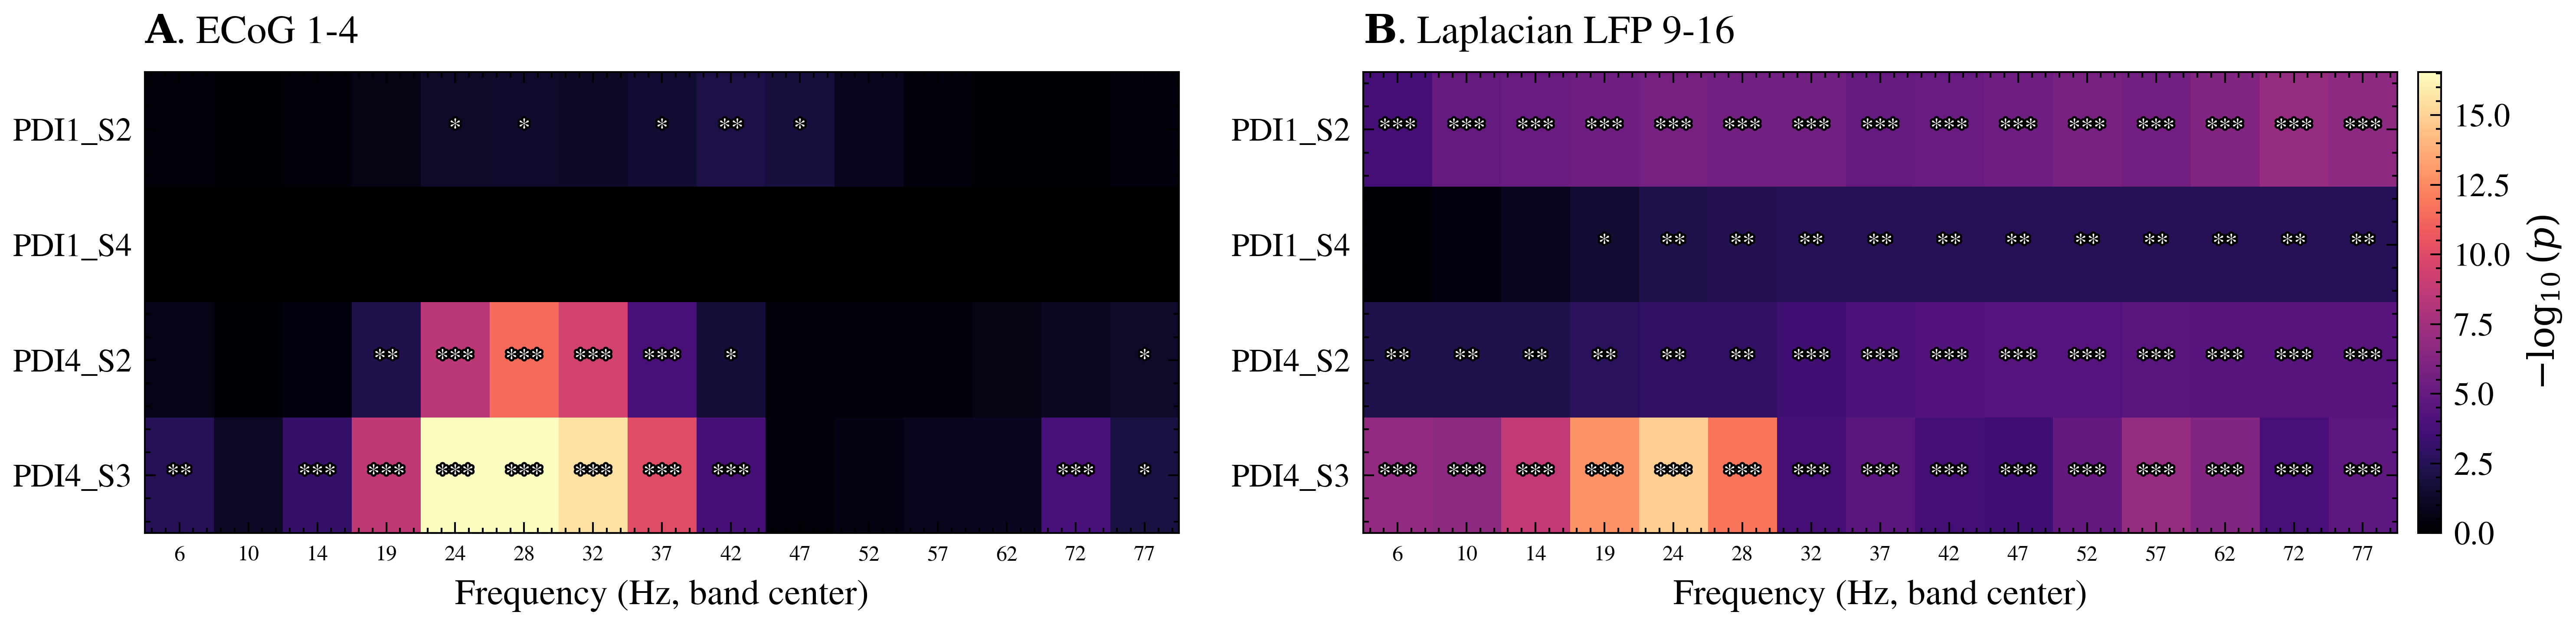

Saved -> fig_006_dbs_significance_heatmap.png


In [6]:
import matplotlib.patheffects as pe
# DBS significance heatmap — ECoG (mean across 4 channels) + Laplacian (mean across 7 channels).

BAND_ORDER = [
    ("theta_4_8", 4, 8),
    ("alpha_8_12", 8, 12),
    ("beta_12_17", 12, 17),
    ("beta_17_22", 17, 22),
    ("beta_22_27", 22, 27),
    ("beta_27_30", 27, 30),
    ("gamma_30_35", 30, 35),
    ("gamma_35_40", 35, 40),
    ("gamma_40_45", 40, 45),
    ("gamma_45_50", 45, 50),
    ("gamma_50_55", 50, 55),
    ("gamma_55_60", 55, 60),
    ("gamma_60_65", 60, 65),
    ("gamma_70_75", 70, 75),
    ("gamma_75_80", 75, 80),
]


def _compute_band_pvals(channel_prefix):
    n_bands = len(BAND_ORDER)
    pmat = np.full((len(session_specs), n_bands), np.nan)
    cols_needed = ["stim"] + [f"{channel_prefix}{bn}_raw" for bn, _, _ in BAND_ORDER]
    for si, s in enumerate(session_specs):
        off_powers, on_powers = [], []
        for fp in _session_raw_files(s.participant, s.session):
            df = pl.read_parquet(fp, columns=cols_needed)
            for row in df.iter_rows(named=True):
                cond = "off" if row["stim"] in ("off", "0") else "on"
                powers = []
                for bn, _, _ in BAND_ORDER:
                    arr = np.array(row[f"{channel_prefix}{bn}_raw"], dtype=float)
                    arr = arr[MARGIN_SAMP:-MARGIN_SAMP]
                    powers.append(np.nanmean(arr**2))
                (off_powers if cond == "off" else on_powers).append(powers)
        if len(off_powers) < 2 or len(on_powers) < 2:
            continue
        off_a, on_a = np.array(off_powers), np.array(on_powers)
        raw_p = np.full(n_bands, np.nan)
        for bi in range(n_bands):
            try:
                _, raw_p[bi] = mannwhitneyu(
                    off_a[:, bi], on_a[:, bi], alternative="two-sided"
                )
            except ValueError:
                pass
        # Benjamini-Hochberg FDR across bands, within this session/channel.
        valid = np.isfinite(raw_p)
        if valid.any():
            adj = false_discovery_control(raw_p[valid])
            pmat[si, np.flatnonzero(valid)] = -np.log10(np.maximum(adj, 1e-20))
    return pmat


print("Computing ECoG band p-values...")
_ecog_pmats = [_compute_band_pvals(f"ECOG_{ch}_") for ch in ECOG_CHANNEL_IDS]
pmat_ecog = np.nanmean(np.stack(_ecog_pmats), axis=0)

print("Computing Laplacian band p-values...")
_lap_pmats = [
    _compute_band_pvals(f"LAPLACIAN_{name}_LFP_") for name in LAP_CHANNEL_NAMES
]
pmat_lap = np.nanmean(np.stack(_lap_pmats), axis=0)

sess_labels = [s.label for s in session_specs]
band_centers = [f"{int((lo + hi) / 2)}" for _, lo, hi in BAND_ORDER]
global_vmax = max(np.nanmax(pmat_ecog), np.nanmax(pmat_lap))

fig, (ax_ecog, ax_lap) = plt.subplots(1, 2, figsize=(10.0, 2.5), layout="constrained")

for ax, pm, letter, title in [
    (ax_ecog, pmat_ecog, "A", "ECoG 1-4"),
    (ax_lap, pmat_lap, "B", "Laplacian LFP 9-16"),
]:
    pm_disp = np.where(np.isfinite(pm), pm, 0)
    im = ax.imshow(
        pm_disp,
        aspect="auto",
        cmap="magma",
        vmin=0,
        vmax=global_vmax,
        interpolation="nearest",
    )
    ax.set_xticks(range(len(BAND_ORDER)))
    ax.set_xticklabels(band_centers, fontsize=6)
    ax.set_yticks(range(len(sess_labels)))
    ax.set_yticklabels(sess_labels)
    ax.set_xlabel("Frequency (Hz, band center)")
    panel_label(ax, letter, title)
    for si in range(len(session_specs)):
        for bi in range(len(BAND_ORDER)):
            val = pm[si, bi]
            if not np.isfinite(val):
                continue
            star = "***" if val > 3 else "**" if val > 2 else "*" if val > -np.log10(0.05) else ""
            if star:
                ax.text(
                    bi, si, star, ha="center", va="center", fontsize=7, color="white",
                    path_effects=[pe.withStroke(linewidth=1.2, foreground="black")],
                )

fig.colorbar(im, ax=ax_lap, label=r"$-\log_{10}(p)$", fraction=0.05, pad=0.02)
fig.savefig(str(OUT / "fig_006_dbs_significance_heatmap.png"))
plt.show()
print("Saved -> fig_006_dbs_significance_heatmap.png")

# envelopes or band powers comparisons.
# significant differences in the power spectra.
# multiple testing (cluster permutation test, mne.)

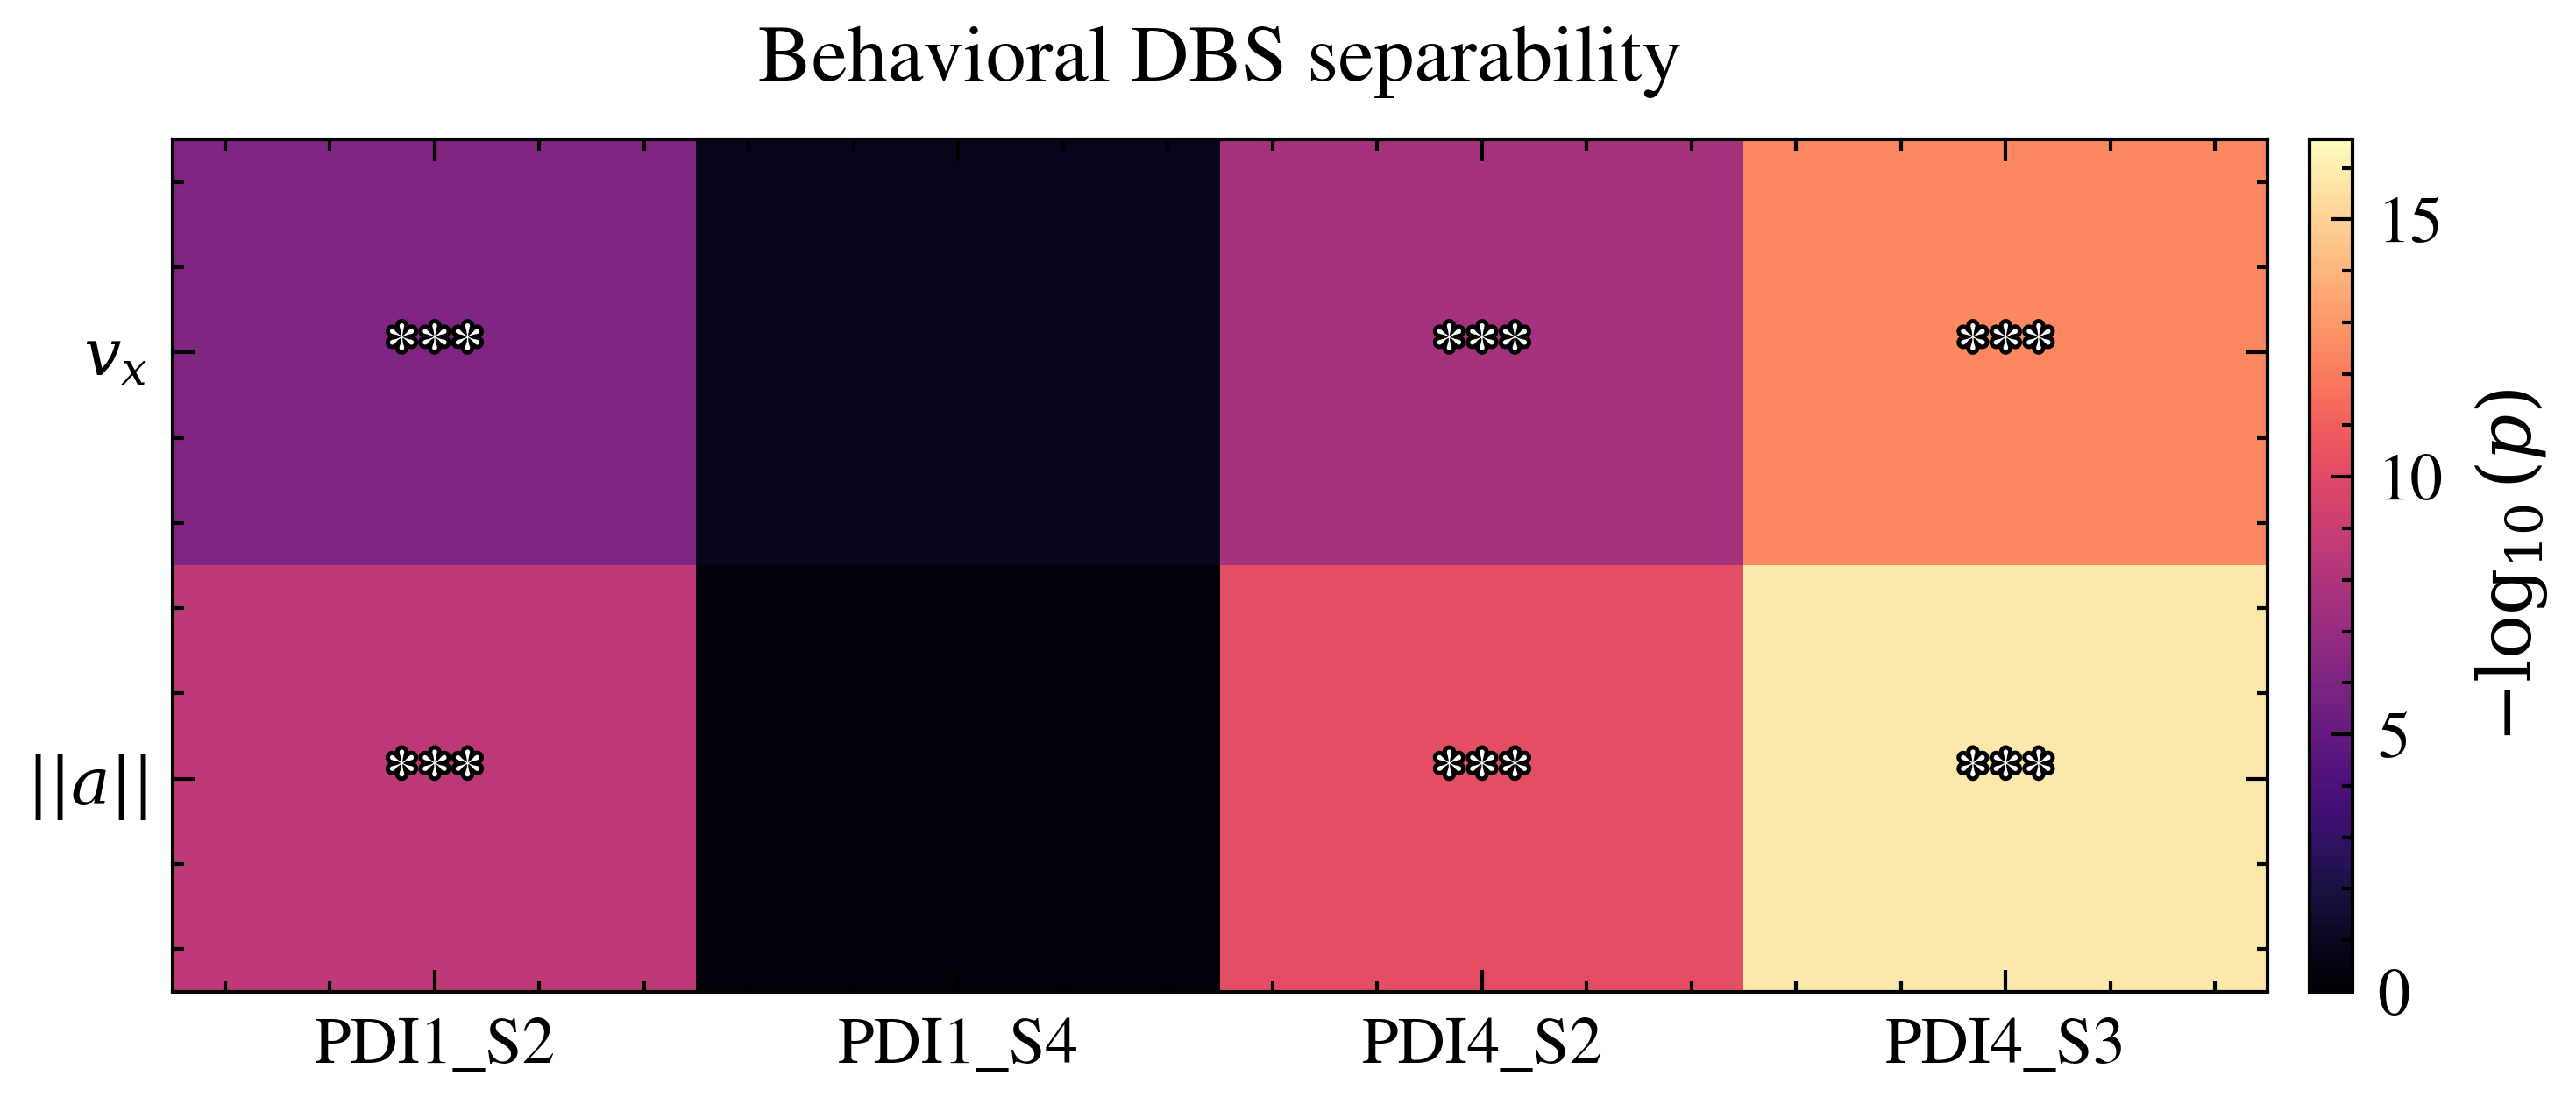

Saved -> fig_006b_beh_dbs_separability.png


In [7]:
import matplotlib.patheffects as pe
# Behavioral DBS separability — tracing_velocity_x & tracing_acceleration_magnitude.
# Per-trial RMS, Mann-Whitney U (DBS-ON vs OFF). Same colorscale as neural heatmap (global_vmax).

BEH_VARS = ["tracing_velocity_x", "tracing_acceleration_magnitude"]
BEH_LABELS = ["$v_x$", "$||a||$"]

beh_pmat = np.full((len(BEH_VARS), len(session_specs)), np.nan)  # (vars × sessions)

for si, s in enumerate(session_specs):
    fw = s.psid_variant.split("_")[0]
    base = results_root / fw / s.psid_variant / "split"
    rms_by_var = {v: {"off": [], "on": []} for v in BEH_VARS}
    for split_name in ("train", "val", "test"):
        fp = base / f"{split_name}.parquet"
        if not fp.exists():
            continue
        df = pl.read_parquet(fp, columns=["stim"] + BEH_VARS)
        for row in df.iter_rows(named=True):
            cond = "off" if row["stim"] in ("off", "0") else "on"
            for v in BEH_VARS:
                sig = np.array(row[v], dtype=float)
                sig = sig[np.isfinite(sig)]
                if len(sig) < 10:
                    continue
                rms_by_var[v][cond].append(np.sqrt(np.mean(sig**2)))
    raw_p = np.full(len(BEH_VARS), np.nan)
    for bi, v in enumerate(BEH_VARS):
        off_vals, on_vals = rms_by_var[v]["off"], rms_by_var[v]["on"]
        if len(off_vals) < 2 or len(on_vals) < 2:
            continue
        try:
            _, raw_p[bi] = mannwhitneyu(off_vals, on_vals, alternative="two-sided")
        except ValueError:
            pass
    # Benjamini-Hochberg FDR across the behavioral variables, within this session.
    valid = np.isfinite(raw_p)
    if valid.any():
        adj = false_discovery_control(raw_p[valid])
        beh_pmat[np.flatnonzero(valid), si] = -np.log10(np.maximum(adj, 1e-20))

sess_labels = [s.label for s in session_specs]
fig, ax = plt.subplots(figsize=(5.0, 2.2), layout="constrained")
ax.set_title("Behavioral DBS separability")
pm_disp = np.where(np.isfinite(beh_pmat), beh_pmat, 0)
im = ax.imshow(
    pm_disp,
    aspect="auto",
    cmap="magma",
    vmin=0,
    vmax=global_vmax,
    interpolation="nearest",
)
ax.set_xticks(range(len(session_specs)))
ax.set_xticklabels(sess_labels)
ax.set_yticks(range(len(BEH_VARS)))
ax.set_yticklabels(BEH_LABELS)

for bi in range(len(BEH_VARS)):
    for si in range(len(session_specs)):
        val = beh_pmat[bi, si]
        if not np.isfinite(val):
            continue
        star = "***" if val > 3 else "**" if val > 2 else "*" if val > -np.log10(0.05) else ""
        if star:
            ax.text(
                si, bi, star, ha="center", va="center", fontsize=9, color="white",
                path_effects=[pe.withStroke(linewidth=1.2, foreground="black")],
            )

fig.colorbar(im, ax=ax, label=r"$-\log_{10}(p)$", fraction=0.06, pad=0.02)
fig.savefig(str(OUT / "fig_006b_beh_dbs_separability.png"))
plt.show()
print("Saved -> fig_006b_beh_dbs_separability.png")

## PSID hyperparameter selection (nx, n1)

nx chosen by peak Z Pearson's r on the validation set,
sweeping nx ∈ {4, 8, 16, 32, 64} with n1 fixed. All sessions converge to nx = 64.

n1 chosen by peak Z Pearson's r on the validation set, sweeping n1 ∈ {1, 2, 4, 8, 16, 32}
with nx = 64. Evaluated separately for z-as-behavior (orange) and z-as-neural (blue).
Dotted vertical lines mark the chosen value per experiment.

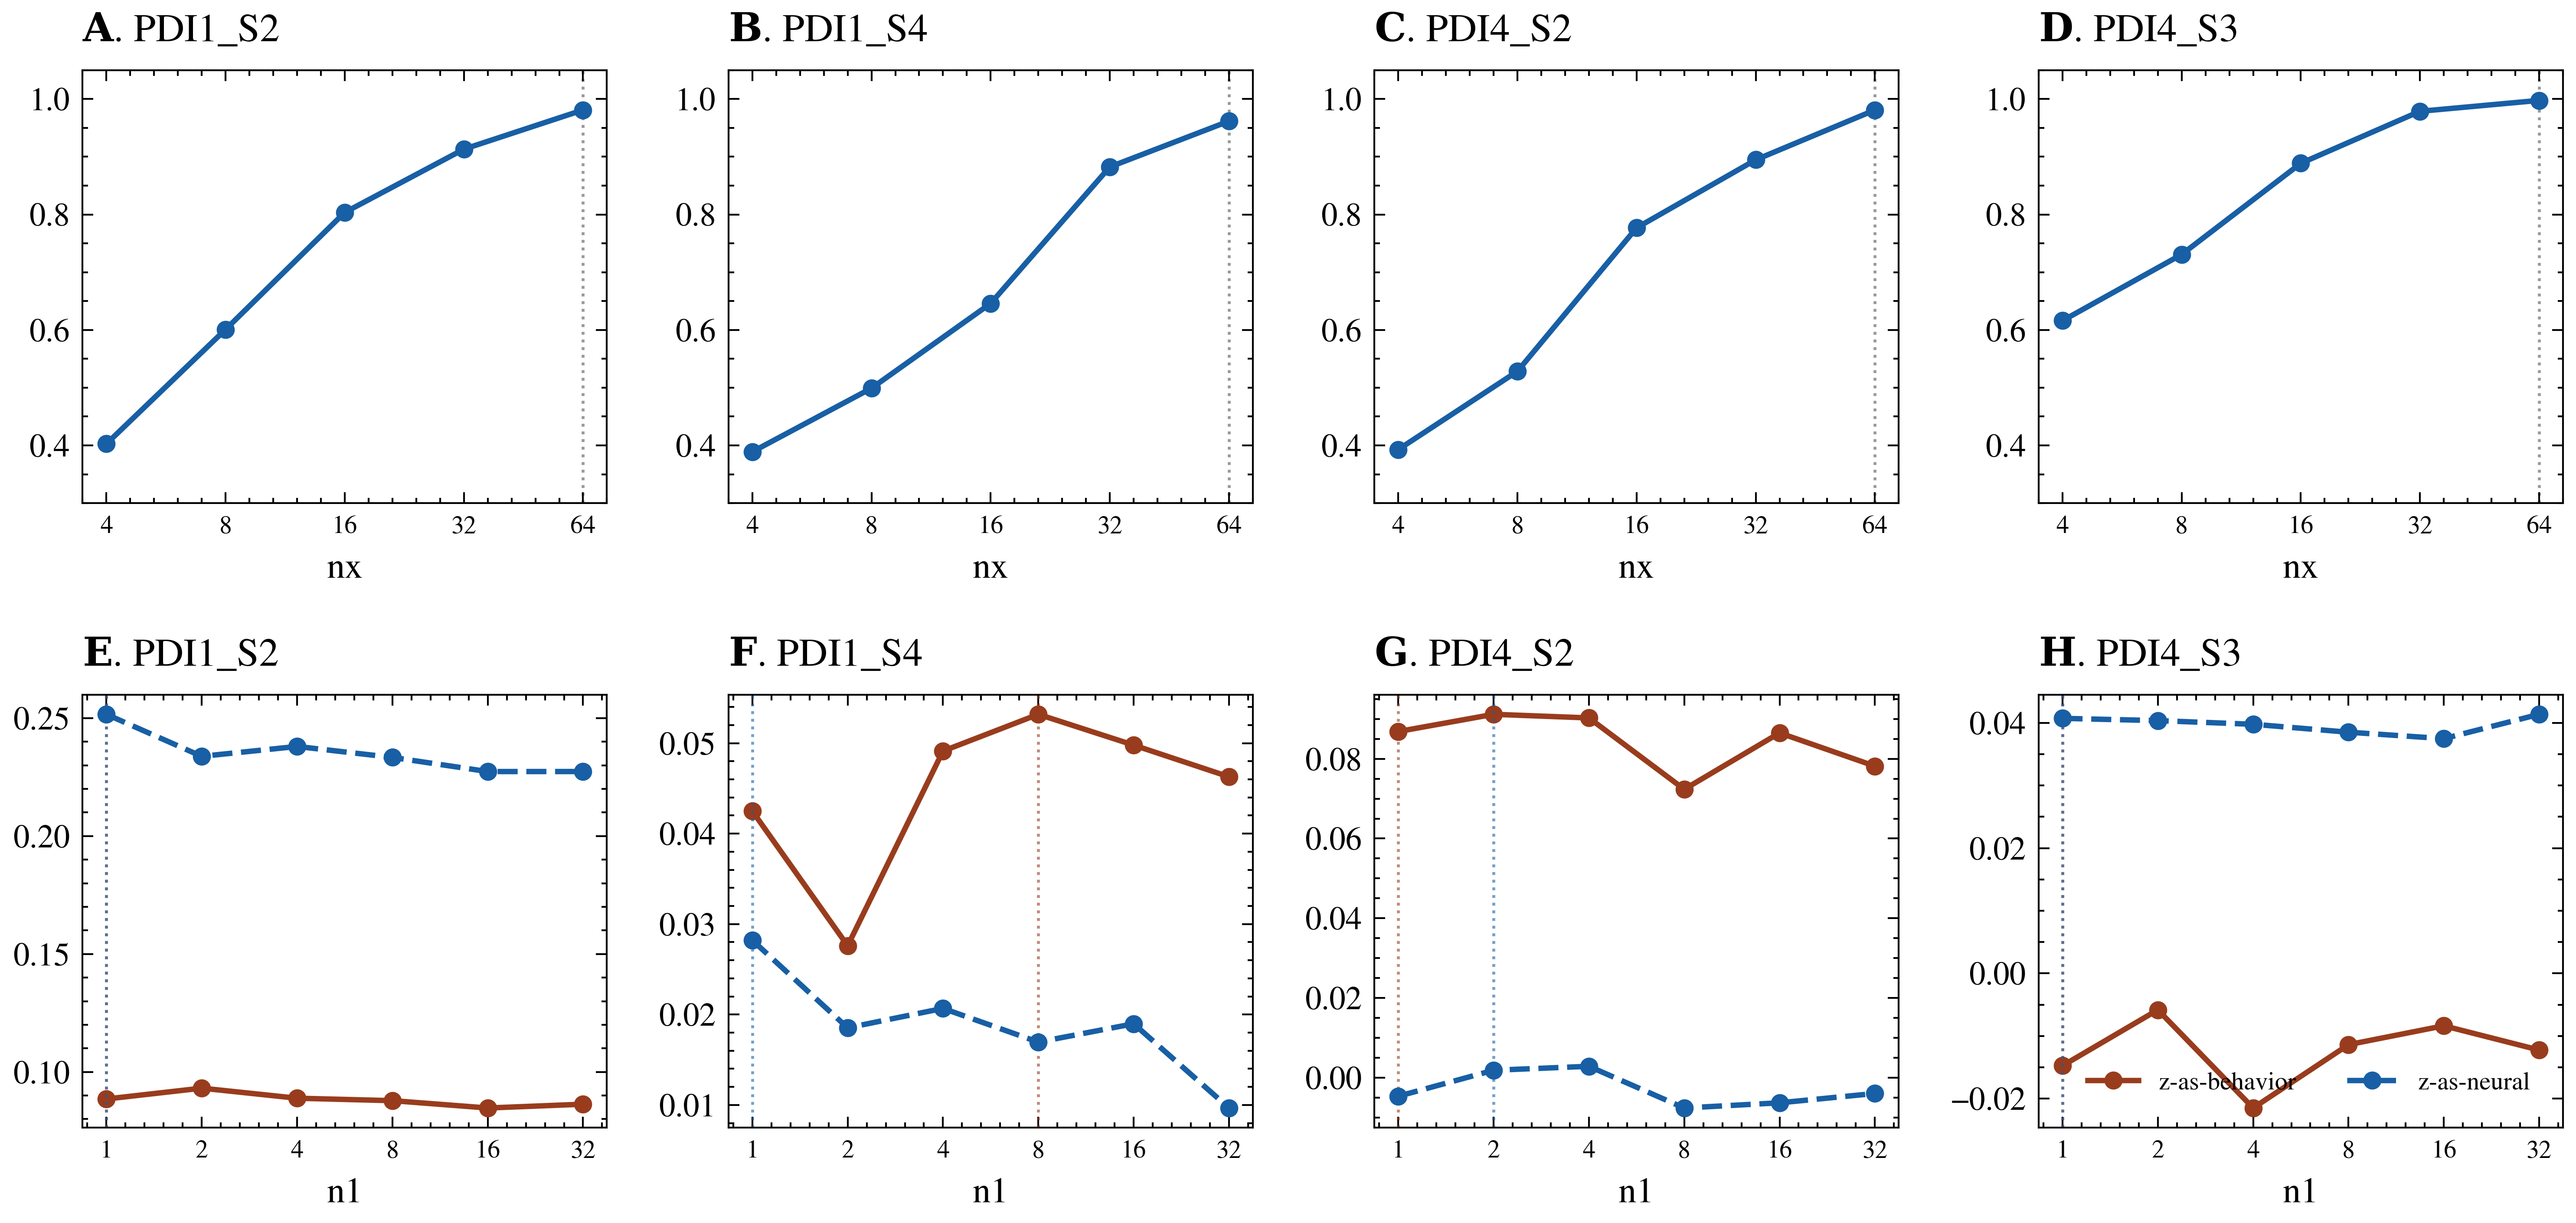

PSID hyperparameter selection. Top row (A-D): Z Pearson's r vs nx on the validation set — all 4 sessions select nx=64 (dotted line). Bottom row (E-H): Z Pearson's r vs n1 on the validation set — orange=z-as-behavior, blue=z-as-neural; dotted verticals mark the chosen n1 per experiment. n1_grid=[1,2,4,8,16,32]; nx_grid=[4,8,16,32,64].


In [8]:
diag_root = results_root / "psid_diagnostic"

diag_data = {}
for sess in SESSIONS:
    diag_data[sess] = {}
    for exp in [EXP_Z_AS_BEHAVIOR, EXP_Z_AS_NEURAL]:
        dirs = sorted((diag_root / f"{sess}_{exp}").glob("*/"))
        df = pl.read_parquet(dirs[-1] / "diagnostic.parquet")
        diag_data[sess][exp] = df.row(0, named=True)

fig, axes = plt.subplots(2, 4, figsize=(10.0, 4.8), constrained_layout=True)

for col, sess in enumerate(SESSIONS):
    # Row 0: nx selection — Z Pearson's r vs nx (same for both experiments)
    ax = axes[0, col]
    row = diag_data[sess][EXP_Z_AS_BEHAVIOR]
    nx_grid = list(row["nx_grid"])
    nx_val = list(row["nx_val_mean"])
    chosen_nx = row["chosen_nx"]
    x_nx = list(range(len(nx_grid)))
    ax.plot(x_nx, nx_val, color=COLOR_PSID, marker="o", ms=4, lw=1.5)
    ax.axvline(nx_grid.index(chosen_nx), color="#999", lw=0.8, ls=":", zorder=0)
    ax.set_xticks(x_nx)
    ax.set_xticklabels([str(v) for v in nx_grid], fontsize=7)
    ax.set_ylim(0.3, 1.05)
    ax.set_xlabel("nx")
    panel_label(ax, chr(65 + col), sess)

    # Row 1: n1 selection — Z Pearson's r vs n1, separate per experiment
    ax = axes[1, col]
    n1_grid = None
    for exp, color in [(EXP_Z_AS_BEHAVIOR, COLOR_DPAD), (EXP_Z_AS_NEURAL, COLOR_PSID)]:
        row = diag_data[sess][exp]
        n1_grid = list(row["n1_grid"])
        n1_z = list(row["n1_z_mean"])
        chosen_n1 = row["chosen_n1"]
        x_n1 = list(range(len(n1_grid)))
        lbl = exp if col == len(SESSIONS) - 1 else None
        ax.plot(x_n1, n1_z, color=color, marker="o", ms=4, lw=1.5, label=lbl)
        ax.axvline(n1_grid.index(chosen_n1), color=color, lw=0.8, ls=":", alpha=0.6)
    ax.set_xticks(list(range(len(n1_grid))))
    ax.set_xticklabels([str(v) for v in n1_grid], fontsize=7)
    ax.set_xlabel("n1")
    panel_label(ax, chr(69 + col), sess)

axes[1, -1].legend(loc="lower right", ncol=2, fontsize=7)
fig.savefig(str(OUT / "fig_007_nx_n1_selection.png"))
plt.show()
print(
    "PSID hyperparameter selection. Top row (A-D): Z Pearson's r vs nx on the "
    "validation set — all 4 sessions select nx=64 (dotted line). "
    "Bottom row (E-H): Z Pearson's r vs n1 on the validation set — orange=z-as-behavior, "
    "blue=z-as-neural; dotted verticals mark the chosen n1 per experiment. "
    "n1_grid=[1,2,4,8,16,32]; nx_grid=[4,8,16,32,64]."
)

## DPAD training curves (4-stage convergence)

DPAD trains in 4 sequential internal stages: model1 -> model1_Cy -> model2 -> model2_Cz
(see CLAUDE.md model hierarchy). Each panel concatenates all 4 stages along the x-axis;
dotted verticals mark stage boundaries. Solid = train NRMSE, dashed = validation NRMSE.
Top row = z-as-neural, bottom row = z-as-behavior. Canonical
dbs_both run per session (same run used elsewhere in sec2/sec5).

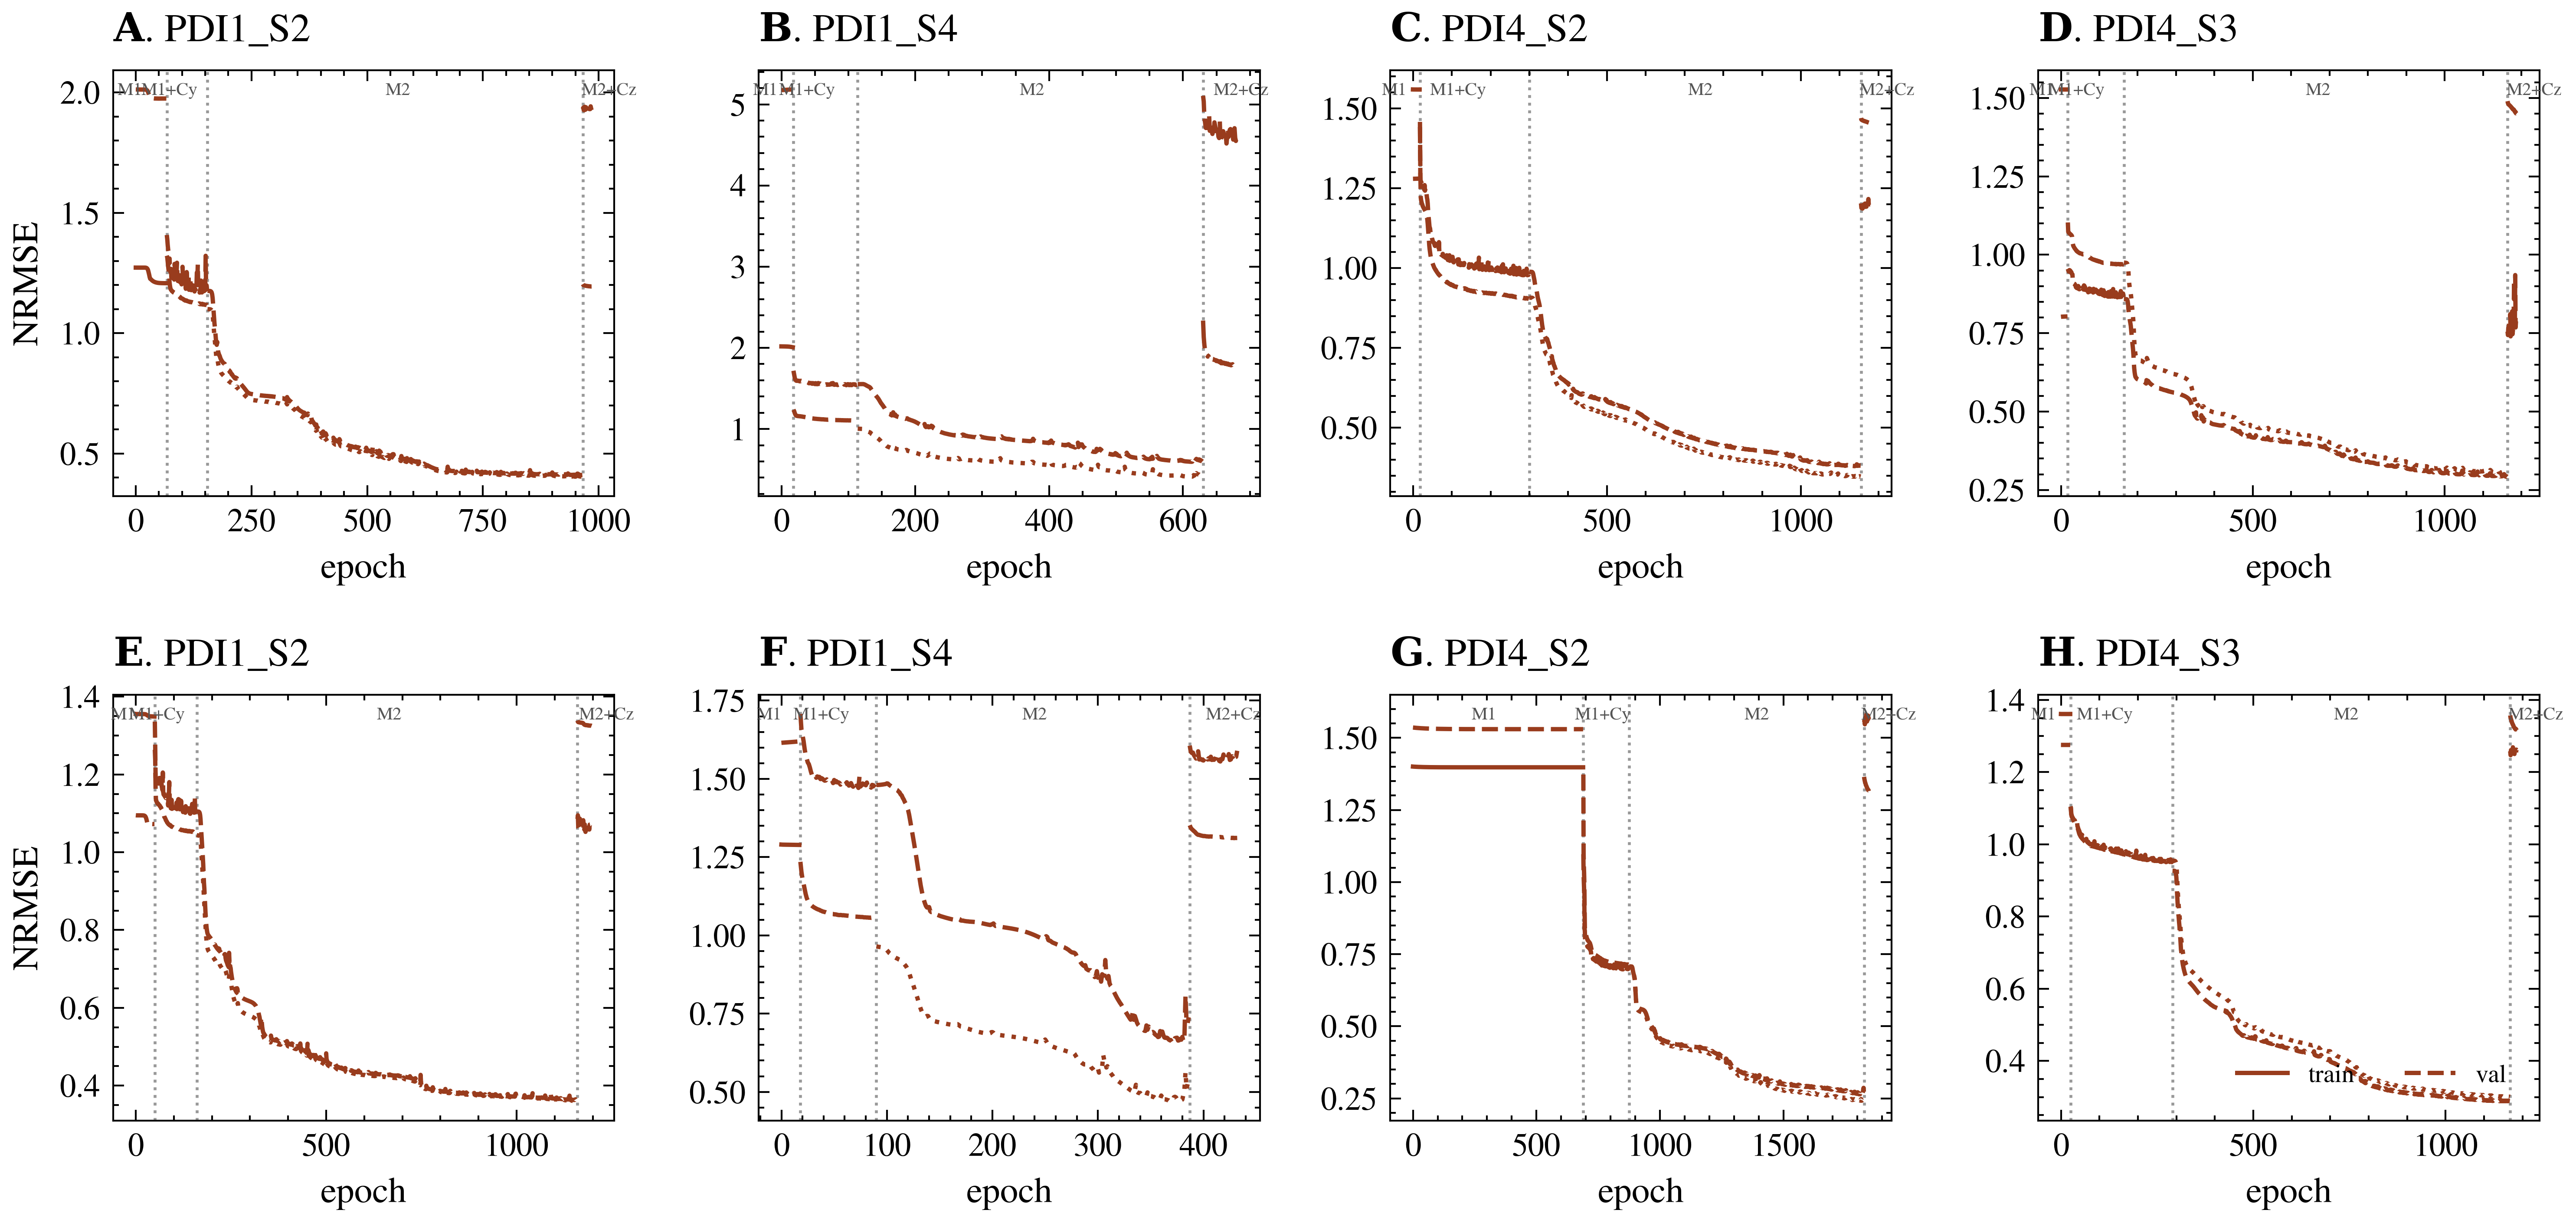

DPAD 4-stage training convergence (M1=model1, M1+Cy=model1_Cy, M2=model2, M2+Cz=model2_Cz). Top row (A-D): z-as-neural; bottom row (E-H): z-as-behavior. Solid = train NRMSE, dashed = validation NRMSE; dotted verticals mark stage boundaries. Canonical dbs_both run per session.


In [9]:
DPAD_STAGES = ["model1", "model1_Cy", "model2", "model2_Cz"]
DPAD_STAGE_LABELS = ["M1", "M1+Cy", "M2", "M2+Cz"]

dpad_history = {}
for sess in SESSIONS:
    dpad_history[sess] = {}
    for exp in [EXP_Z_AS_NEURAL, EXP_Z_AS_BEHAVIOR]:
        vdir = get_latest_variant_dir(
            results_root, "dpad", exp, sess, condition="dbs_both"
        )
        base_dir = vdir.parent / vdir.name.removesuffix("_dbs_both")
        with open(base_dir / "training_history.json") as f:
            dpad_history[sess][exp] = json.load(f)

fig, axes = plt.subplots(2, 4, figsize=(10.0, 4.8), constrained_layout=True)

for col, sess in enumerate(SESSIONS):
    for row_idx, exp in enumerate([EXP_Z_AS_NEURAL, EXP_Z_AS_BEHAVIOR]):
        ax = axes[row_idx, col]
        hist = dpad_history[sess][exp]

        stage_ranges = []
        offset = 0
        for stage in DPAD_STAGES:
            n_epoch = len(hist[stage]["epochs"])
            stage_ranges.append((offset, offset + n_epoch))
            offset += n_epoch
        total_epochs = offset

        for si, stage in enumerate(DPAD_STAGES):
            x_start, x_end = stage_ranges[si]
            x = list(range(x_start, x_end))
            ax.plot(x, hist[stage]["rmse"], color=COLOR_DPAD, lw=1.2)
            ax.plot(x, hist[stage]["val_rmse"], color=COLOR_DPAD, lw=1.2, ls="--")
            if si < len(DPAD_STAGES) - 1:
                ax.axvline(x_end, color="#999", lw=0.8, ls=":", zorder=0)
            x_frac = (x_start + x_end) / 2 / total_epochs
            ax.text(x_frac, 0.97, DPAD_STAGE_LABELS[si],
                    transform=ax.transAxes, ha="center", va="top",
                    fontsize=5, color="#555")

        ax.set_xlabel("epoch")
        if col == 0:
            ax.set_ylabel("NRMSE")
        letter = chr(65 + col) if row_idx == 0 else chr(69 + col)
        panel_label(ax, letter, sess)

axes[-1, -1].plot([], [], color=COLOR_DPAD, lw=1.2, label="train")
axes[-1, -1].plot([], [], color=COLOR_DPAD, lw=1.2, ls="--", label="val")
axes[-1, -1].legend(loc="lower right", ncol=2, fontsize=7)
fig.savefig(str(OUT / "fig_008_dpad_training_curves.png"))
plt.show()
print(
    "DPAD 4-stage training convergence (M1=model1, M1+Cy=model1_Cy, M2=model2, M2+Cz=model2_Cz). "
    "Top row (A-D): z-as-neural; bottom row (E-H): z-as-behavior. Solid = train NRMSE, "
    "dashed = validation NRMSE; dotted verticals mark stage boundaries. "
    "Canonical dbs_both run per session."
)

## Section 3.0 — Bullet points (copy into thesis)

- **Trial counts.** After removing fragmented blocks and plateau trials (cursor stationary > 2 s), usable trial counts were 144 (PDI1\_S2), 116 (PDI1\_S4), 119 (PDI4\_S2), and 120 (PDI4\_S3). Trials were split chronologically into train / val / test sets; DBS-ON and DBS-OFF conditions were balanced in train and test splits for all sessions. Note: PDI4\_S3 validation set contains only DBS-ON trials (0 DBS-OFF) due to the chronological split landing on a pure-ON block.

- **PSD separation.** PDI4\_S2 and PDI4\_S3 show consistent DBS-ON vs DBS-OFF power differences across gamma-band frequencies (30–80 Hz), with Mann-Whitney U tests reaching $p < 0.05$ in multiple bands for both ECoG and Laplacian channels. PDI1\_S2 and PDI1\_S4 show little to no spectral separation between conditions across all bands and channel types.

- **Spectral separability ceiling.** The absence of DBS-modulated signal in PDI1 sessions imposes a hard ceiling on any decoding approach: models cannot recover state information that is not encoded in the neural signal. Chance-level decoding performance on PDI1 throughout all subsequent RQs should be interpreted as a data property rather than a model failure.

- **Behavioral kinematics.** Mean velocity and acceleration traces are visually similar between DBS-ON and DBS-OFF conditions in all four sessions (overlapping SEM bands), consistent with the cursor-tracing task being self-paced and not directly modulated by stimulation at the kinematic level.

## Verification prints (traceability for 04_00)


In [10]:
from modules.utils import normalize_stim
# --- Printed source for 04_00 neural DBS significance (backs band ranges + per-session p) ---
def _sig_bands(pm_row):
    out = []
    for (bn, lo, hi), val in zip(BAND_ORDER, pm_row):
        if not np.isfinite(val):
            continue
        p = 10.0 ** (-val)
        star = "***" if val > 3 else "**" if val > 2 else "*" if val > -np.log10(0.05) else ""
        if star:
            out.append(f"{lo}-{hi}Hz{star}(p={p:.1e})")
    return out

print("DBS band significance per session (Mann-Whitney U, ECoG mean ch1-4):")
for si, lab in enumerate(sess_labels):
    b = _sig_bands(pmat_ecog[si])
    print(f"  {lab:10s} {', '.join(b) if b else 'none <0.05'}")
print("\nDBS band significance per session (Laplacian LFP mean ch9-16):")
for si, lab in enumerate(sess_labels):
    b = _sig_bands(pmat_lap[si])
    print(f"  {lab:10s} {', '.join(b) if b else 'none <0.05'}")


DBS band significance per session (Mann-Whitney U, ECoG mean ch1-4):
  PDI1_S2    22-27Hz*(p=4.4e-02), 27-30Hz*(p=4.0e-02), 35-40Hz*(p=3.1e-02), 40-45Hz**(p=8.2e-03), 45-50Hz*(p=1.3e-02)
  PDI1_S4    none <0.05
  PDI4_S2    17-22Hz**(p=5.1e-03), 22-27Hz***(p=2.9e-09), 27-30Hz***(p=3.9e-12), 30-35Hz***(p=4.1e-10), 35-40Hz***(p=1.8e-04), 40-45Hz*(p=1.9e-02), 75-80Hz*(p=4.8e-02)
  PDI4_S3    4-8Hz**(p=2.7e-03), 12-17Hz***(p=8.7e-04), 17-22Hz***(p=2.2e-09), 22-27Hz***(p=3.0e-17), 27-30Hz***(p=2.8e-17), 30-35Hz***(p=2.7e-16), 35-40Hz***(p=9.0e-11), 40-45Hz***(p=1.9e-04), 70-75Hz***(p=1.3e-04), 75-80Hz*(p=1.1e-02)

DBS band significance per session (Laplacian LFP mean ch9-16):
  PDI1_S2    4-8Hz***(p=1.9e-04), 8-12Hz***(p=9.2e-06), 12-17Hz***(p=7.6e-06), 17-22Hz***(p=4.1e-06), 22-27Hz***(p=2.0e-06), 27-30Hz***(p=2.8e-06), 30-35Hz***(p=3.0e-06), 35-40Hz***(p=9.2e-06), 40-45Hz***(p=7.4e-06), 45-50Hz***(p=4.3e-06), 50-55Hz***(p=1.6e-06), 55-60Hz***(p=2.4e-06), 60-65Hz***(p=5.4e-07), 70-75Hz***(

In [11]:
# --- Printed source for 04_00 behavior significance + split-seconds table ---
print("Behavioral DBS separability p (Mann-Whitney U per session):")
print(f"  {'session':10s} {'v_x':>12s} {'||a||':>12s}")
for si, lab in enumerate(sess_labels):
    ps = []
    for bi in range(len(BEH_VARS)):
        val = beh_pmat[bi, si]
        ps.append(f"{10.0**(-val):.1e}" if np.isfinite(val) else "n/a")
    print(f"  {lab:10s} {ps[0]:>12s} {ps[1]:>12s}")

print("\nUsable data per split (seconds; OFF/ON trial counts), 1 trial = 9 s:")
print(f"  {'session':10s} {'split':6s} {'sec':>7s} {'off':>4s} {'on':>4s}")
for s in session_specs:
    fw = s.psid_variant.split("_")[0]
    base = results_root / fw / s.psid_variant / "split"
    tot = 0
    for split_name in ("train", "val", "test"):
        fp = base / f"{split_name}.parquet"
        if not fp.exists():
            continue
        df = pl.read_parquet(fp, columns=["stim"])
        stims = [normalize_stim(v) for v in df["stim"].to_list()]
        n_off = sum(1 for v in stims if v == "off")
        n_on = sum(1 for v in stims if v == "on")
        tot += 9 * len(df)
        print(f"  {s.label:10s} {split_name:6s} {9*len(df):7d} {n_off:4d} {n_on:4d}")
    print(f"  {s.label:10s} {'TOTAL':6s} {tot:7d}")


Behavioral DBS separability p (Mann-Whitney U per session):
  session             v_x        ||a||
  PDI1_S2         8.0e-07      2.8e-09
  PDI1_S4         1.3e-01      5.2e-01
  PDI4_S2         2.3e-08      5.4e-11
  PDI4_S3         3.4e-13      1.7e-16

Usable data per split (seconds; OFF/ON trial counts), 1 trial = 9 s:
  session    split      sec  off   on
  PDI1_S2    train      648   36   36
  PDI1_S2    val        216   12   12
  PDI1_S2    test       432   24   24
  PDI1_S2    TOTAL     1296
  PDI1_S4    train      432   24   24
  PDI1_S4    val        207   12   11
  PDI1_S4    test       405   22   23
  PDI1_S4    TOTAL     1044
  PDI4_S2    train      423   24   23
  PDI4_S2    val        216   12   12
  PDI4_S2    test       432   24   24
  PDI4_S2    TOTAL     1071
  PDI4_S3    train      432   24   24
  PDI4_S3    val        216    0   24
  PDI4_S3    test       432   24   24
  PDI4_S3    TOTAL     1080
